In [ ]:
#Q1
import numpy as np
import random
import matplotlib.pyplot as plt

# Tree node
class Node:
    def __init__(self, address, parent=None):
        self.address = address
        self.parent = parent
        self.children = {}
        self.visit_counts = 0
        self.total_value = 0

# MCTS Implementation

class MCTS:
    def __init__(self, max_depth, C, leaf_values, max_iterations_per_root, num_rollouts):
        self.max_iterations_per_root = max_iterations_per_root
        self.max_depth = max_depth
        self.C = C
        self.leaf_values = leaf_values
        self.num_rollouts = num_rollouts
        self.root = Node("")
        self.rng = random.Random(42)
        self.visited_nodes = set()

    # Get UCB score
    def UCB_score(self, child, parent):
        if child.visit_counts == 0:
            return float("inf")
        return (child.total_value / child.visit_counts) + self.C * np.sqrt(np.log(parent.visit_counts) / child.visit_counts)


    # Choose a snowcap leaf node
    def select(self):
        node = self.root

        while len(node.address) < self.max_depth:

            if len(node.children) != 2:
                return node  # stop at unexplored child

            # choose the child with max UCB
            right_score = self.UCB_score(node.children["R"], node)
            left_score = self.UCB_score(node.children["L"], node)

            if right_score >= left_score:
              node = node.children["R"]
            else:
              node=  node.children["L"]

        return node

    # Choose a random unexplored child from snowcap leaf node to start roll out at
    def expand(self, node):
        if len(node.address) == self.max_depth:
            return node

        unexplored = [a for a in ["L", "R"] if a not in node.children]

        if len(unexplored) == 1:
          choice = unexplored[0]
        else:
          choice = self.rng.choice(unexplored)

        child = Node(node.address + choice, parent=node)
        node.children[choice] = child

        return child

    # Perform a random roll out from child of snowcap leaf node
    def random_roll_out(self, child):
        address = child.address
        while len(address) < self.max_depth:
            choice = self.rng.choice(["L", "R"])
            address += choice
        return self.leaf_values[address]

    # Backpropagate reward value back up from start of roll out to root
    def back_prop(self, child, reward):
        node = child
        while node is not None:
            node.total_value += reward
            node.visit_counts += 1
            self.visited_nodes.add(node)
            node = node.parent

    # Run MCTS algorithm on a particular root till budget exhausted
    def MCTS_on_a_root(self):
        for _ in range(self.max_iterations_per_root):
            leaf = self.select()
            child = self.expand(leaf)
            reward = 0
            for _ in range(self.num_rollouts):
              reward += self.random_roll_out(child)
            reward = reward / self.num_rollouts
            self.back_prop(child, reward)


# Run the MCTS algorithm
def run_MCTS(max_iterations_per_root, C, leaf_values, max_depth, num_rollouts):
    mcts = MCTS(max_depth, C, leaf_values, max_iterations_per_root, num_rollouts)

    for _ in range(max_depth):
        mcts.MCTS_on_a_root()

        # choose new root = best child
        left = mcts.root.children.get("L")
        right = mcts.root.children.get("R")

        if mcts.UCB_score(right, mcts.root) >= mcts.UCB_score(left, mcts.root):
          mcts.root = right
        else:
          mcts.root = left

        mcts.root.parent = None

    return leaf_values[mcts.root.address], mcts.root.address, mcts.visited_nodes


def edit_distance(a, b):
    return sum(x != y for x, y in zip(a, b))

def get_addresses(max_depth):
    addresses = [""]
    for _ in range(max_depth):
        new = []
        for addr in addresses:
            new.append(addr + "L")
            new.append(addr + "R")
        addresses = new
    return addresses

# Get the scores of all the leaves
def get_leaf_scores(target_address, max_depth):
    all_addresses = get_addresses(max_depth)
    ed = {addr: edit_distance(addr, target_address) for addr in all_addresses}

    B = 10
    tau = max(ed.values()) / 5

    leaf_scores = {}
    for addr in all_addresses:
        leaf_scores[addr] = B * np.exp(-(ed[addr]/tau)) + np.random.normal()

    return leaf_scores


running C value 0.1
running C value 0.5
running C value 1
running C value 1.5
running C value 1.75
running C value 2
running C value 2.25
running C value 2.5
running C value 3
running C value 4
running C value 5
running C value 7.5
running C value 10


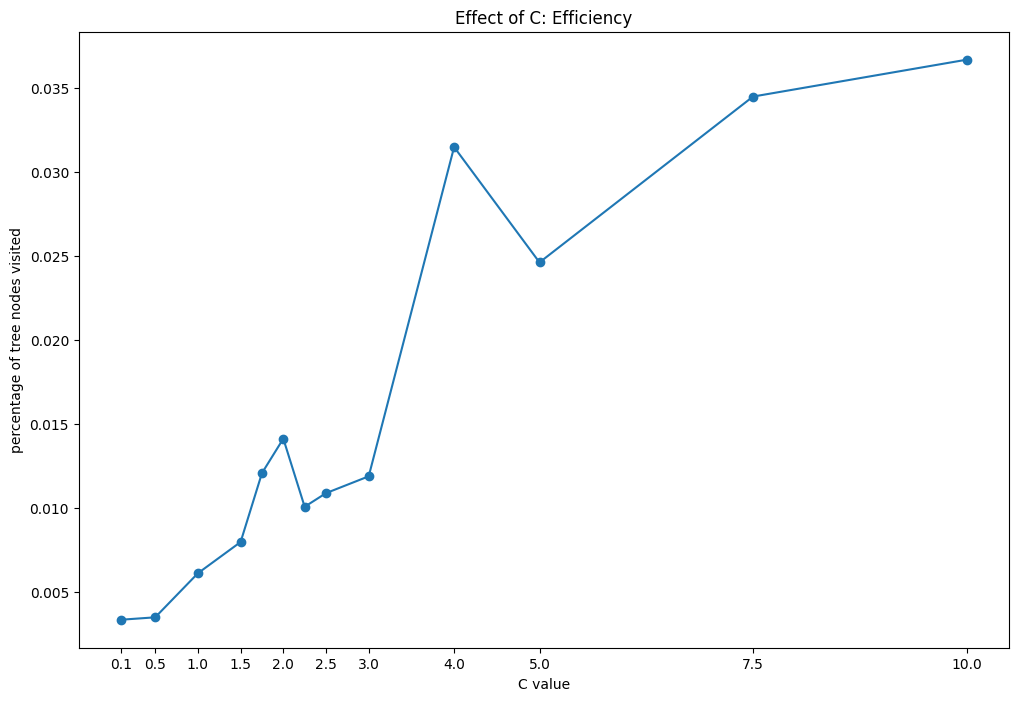

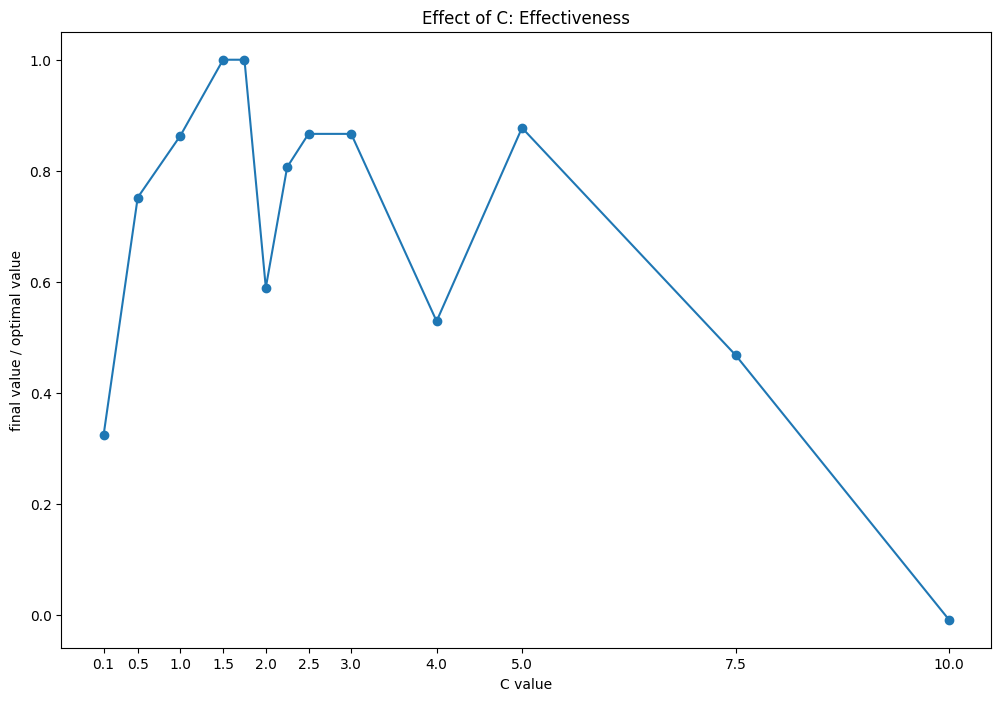

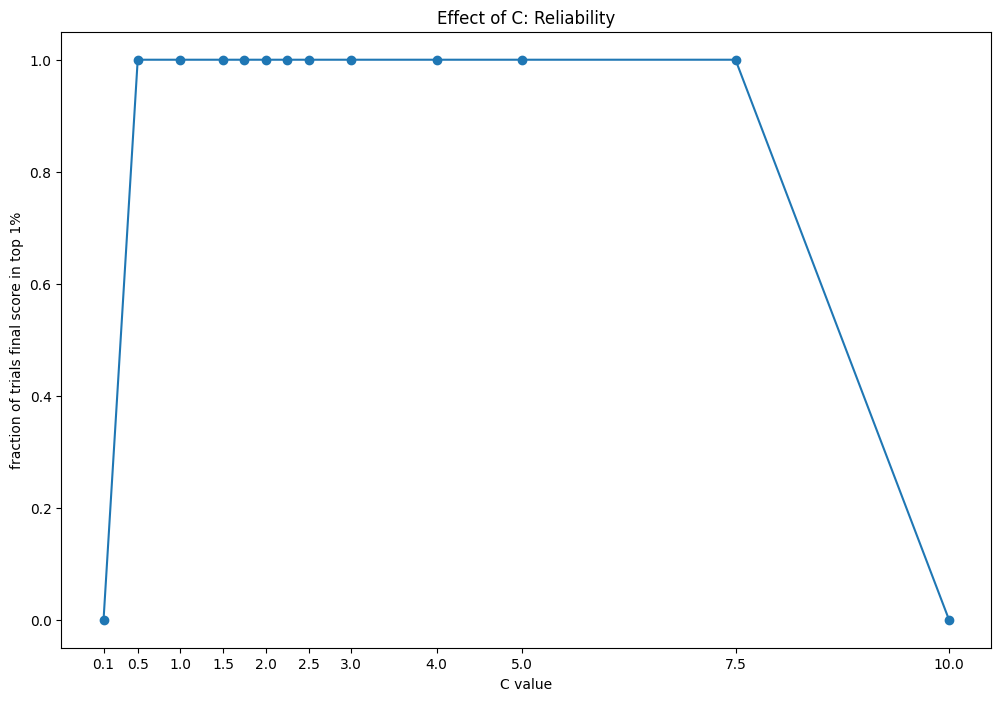

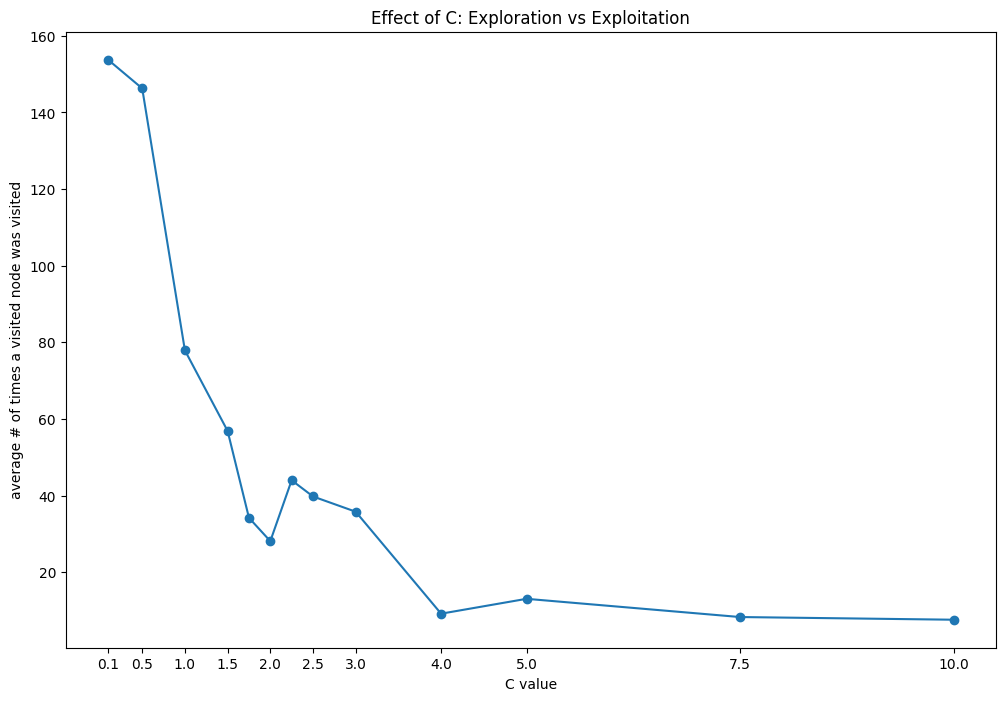

In [ ]:
# Compute the 4 statistics for a run
def compute_metrics(final_value, final_leaf, leaf_values, visited_nodes):
    all_leaves = list(leaf_values.values())
    optimal = max(all_leaves)
    top10_cutoff = np.percentile(all_leaves, 99)

    return {
        "efficiency": (len(visited_nodes) / (2**(max_depth+1) - 1))*100,
        "effectiveness": final_value / optimal,
        "reliability": 1.0 if leaf_values[final_leaf] >= top10_cutoff else 0.0,
        "exploration_vs_exploitation": np.mean([node.visit_counts for node in visited_nodes])
    }

# Run the experiments with different C values
def run_experiments():
    global max_depth
    max_depth = 20
    num_rollouts = 5
    iters_per_root = 50
    N_trials_per_param = 1000

    target = "LLLLLLLLLLRRRRRRRRRR" # Random target node
    if len(target) != 20:
      print(f"ERROR NOT RIGHT LENGTH TARGET")
    leaf_values = get_leaf_scores(target, max_depth)

    C_values = [0.1, 0.5, 1, 1.5, 1.75, 2, 2.25, 2.5, 3, 4, 5, 7.5, 10]



    def sweep(param_list ):
        results = {p: [] for p in param_list}

        for p in param_list:
          print(f"running C value {p}")
          for i in range(N_trials_per_param):
            C = p
            final_value, leaf, visited = run_MCTS(iters_per_root, C, leaf_values, max_depth, num_rollouts)
            metrics = compute_metrics(final_value, leaf, leaf_values, visited)
            results[p].append(metrics)

        # Average results over trials
        summary = {}
        for p in param_list:
            avg = {
                key: np.mean([r[key] for r in results[p]])
                for key in results[p][0]
            }
            summary[p] = avg
        return summary

    sweepC = sweep(C_values)

    # Make plots
    def plot_results(summary, title_prefix):
        params = list(summary.keys())
        eff = [summary[p]["efficiency"] for p in params]
        effec = [summary[p]["effectiveness"] for p in params]
        rel = [summary[p]["reliability"] for p in params]
        explo = [summary[p]["exploration_vs_exploitation"] for p in params]

        plt.figure(figsize=(12, 8))
        plt.plot(params, eff, marker='o')
        plt.title(f"{title_prefix}: Efficiency")
        plt.xlabel("C value")
        plt.ylabel("percentage of tree nodes visited")
        plt.xticks([0.1, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 7.5, 10])
        plt.show()

        plt.figure(figsize=(12, 8))
        plt.plot(params, effec, marker='o')
        plt.title(f"{title_prefix}: Effectiveness")
        plt.xlabel("C value")
        plt.ylabel("final value / optimal value")
        plt.xticks([0.1, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 7.5, 10])
        plt.show()

        plt.figure(figsize=(12, 8))
        plt.plot(params, rel, marker='o')
        plt.title(f"{title_prefix}: Reliability")
        plt.xlabel("C value")
        plt.ylabel("fraction of trials final score in top 1%")
        plt.xticks([0.1, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 7.5, 10])
        plt.show()

        plt.figure(figsize=(12, 8))
        plt.plot(params, explo, marker='o')
        plt.title(f"{title_prefix}: Exploration vs Exploitation")
        plt.xlabel("C value")
        plt.ylabel("average # of times a visited node was visited")
        plt.xticks([0.1, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 7.5, 10])
        plt.show()

    plot_results(sweepC, "Effect of C")

run_experiments()


In [ ]:
#Q2.3
import numpy as np

#Bellman equations 12x12 transition matrix. State 0 is terminal, 1-4 stochastic, 5-11 deterministic.

def compute_values(epsilon):
    """
    Computes v* and optimal policy for noise level epsilon.
    """

    T_L = np.array([
    [1,0,0,0,0,0,0,0,0,0,0,0],
    [1-epsilon,0,epsilon,0,0,0,0,0,0,0,0,0],
    [0,1-epsilon,0,epsilon,0,0,0,0,0,0,0,0],
    [0,0,1-epsilon,0,epsilon,0,0,0,0,0,0,0],
    [0,0,0,1-epsilon,0,epsilon,0,0,0,0,0,0],
    [0,0,0,0,1,0,0,0,0,0,0,0],
    [0,0,0,0,0,1,0,0,0,0,0,0],
    [0,0,0,0,0,0,1,0,0,0,0,0],
    [0,0,0,0,0,0,0,1,0,0,0,0],
    [0,0,0,0,0,0,0,0,1,0,0,0],
    [0,0,0,0,0,0,0,0,0,1,0,0],
    [0,0,0,0,0,0,0,0,0,0,1,0]
    ])

    T_R = np.array([
        [1,0,0,0,0,0,0,0,0,0,0,0],
        [epsilon,0,1-epsilon,0,0,0,0,0,0,0,0,0],
        [0,epsilon,0,1-epsilon,0,0,0,0,0,0,0,0],
        [0,0,epsilon,0,1-epsilon,0,0,0,0,0,0,0],
        [0,0,0,epsilon,0,1-epsilon,0,0,0,0,0,0],
        [0,0,0,0,0,0,1,0,0,0,0,0],
        [0,0,0,0,0,0,0,1,0,0,0,0],
        [0,0,0,0,0,0,0,0,1,0,0,0],
        [0,0,0,0,0,0,0,0,0,1,0,0],
        [0,0,0,0,0,0,0,0,0,0,1,0],
        [0,0,0,0,0,0,0,0,0,0,0,1],
        [1,0,0,0,0,0,0,0,0,0,0,0]
    ])

    R_L = np.array([0, 10-11*epsilon, -1, -1,-1, -1, -1, -1, -1, -1, -1, -1])
    R_R = np.array([0, 11*epsilon-1, -1, -1,-1, -1, -1, -1, -1, -1, -1, 10])

    v = np.zeros(12)

    for i in range(10000):
        v_new = np.zeros(12)
        for s in range(12):
            # Q-values for both actions at state s
            Q_L = R_L[s] + T_L[s] @ v
            Q_R = R_R[s] + T_R[s] @ v

            v_new[s] = max(Q_L, Q_R)

        if np.max(np.abs(v - v_new)) < 1e-12:
            print(f"Converged in {i} iterations.")
            break

        v = v_new

    # extract policy
    policy = []
    for s in range(12):
        Q_L = R_L[s] + T_L[s] @ v
        Q_R = R_R[s] + T_R[s] @ v
        print(f"State {s}: Q_L = {Q_L}, Q_R = {Q_R}")
        # if Q_L == Q_R:
            # print(f"State {s} has equal Q-values for both actions.")
        policy.append("L" if Q_L >= Q_R else "R") #ties broken aribitrarily


    return v, policy

v_02, pi_02 = compute_values(0.2)
print("Value function ε=0.2:", v_02)
print("Policy ε=0.2:", pi_02)
v_045, pi_045 = compute_values(0.45)
print("Value function ε=0.45:", v_045)
print("Policy ε=0.45:", pi_045)

Converged in 71 iterations.
State 0: Q_L = 0.0, Q_R = 0.0
State 1: Q_L = 9.337243401759414, Q_R = 7.348973607037658
State 2: Q_L = 7.68621700879744, Q_R = 5.733137829911475
State 3: Q_L = 6.082111436949394, Q_R = 4.269794721406359
State 4: Q_L = 4.665689149559589, Q_R = 3.4164222873898975
State 5: Q_L = 3.6656891495586805, Q_R = 4.0
State 6: Q_L = 3.0, Q_R = 5.0
State 7: Q_L = 4.0, Q_R = 6.0
State 8: Q_L = 5.0, Q_R = 7.0
State 9: Q_L = 6.0, Q_R = 8.0
State 10: Q_L = 7.0, Q_R = 9.0
State 11: Q_L = 8.0, Q_R = 10.0
Value function ε=0.2: [ 0.          9.3372434   7.68621701  6.08211144  4.66568915  4.
  5.          6.          7.          8.          9.         10.        ]
Policy ε=0.2: ['L', 'L', 'L', 'L', 'L', 'R', 'R', 'R', 'R', 'R', 'R', 'R']
Converged in 125 iterations.
State 0: Q_L = 0.0, Q_R = 0.0
State 1: Q_L = 6.594870522341013, Q_R = 5.838175082861239
State 2: Q_L = 3.4330456052030502, Q_R = 2.952640068061255
State 3: Q_L = 1.7908151509229668, Q_R = 1.6480972721942369
State 4: Q

In [ ]:
#Q2.4
import numpy as np
import random

#seed randomness for reproducibility
random.seed(42)
np.random.seed(42)

def sigmoid(x):
  return 1/(1+np.exp(-x))

def run_MC(num_iterations, theta, epsilon, alpha):

  for i in range(num_iterations):
    s_0 = random.randint(0,11)
    s = s_0
    grad_J = 0

    while s != 0:
      p_R = sigmoid(s - theta)
      move = np.random.binomial(size=1, n=1, p= p_R)[0]
      if move == 1:
        grad_log_pi_wrt_theta = p_R - 1
      else:
        grad_log_pi_wrt_theta = p_R

      if s in [1,2,3,4]:
        execute = np.random.binomial(size=1, n=1, p= (1-epsilon))[0]
        if (move == 1 and execute == 1) or (move == 0 and execute == 0):
          s = (s+1) % 12
        else:
          assert (move == 1 and execute == 0) or (move == 0 and execute == 1), "INVALID MOVE"
          s = (s-1) % 12
        if s == 0:
          grad_J += 10*grad_log_pi_wrt_theta
        else:
          grad_J += -1*grad_log_pi_wrt_theta
      else:
        if move == 1:
          s = (s+1) % 12
        else:
          s = (s-1) % 12

        if s == 0:
          grad_J += 10*grad_log_pi_wrt_theta
        else:
          grad_J += -1*grad_log_pi_wrt_theta

    theta += alpha*grad_J

  return theta


thetas = []
for i in range(100000):
  theta = run_MC(1000, 0, 0.45, 0.1)
  thetas.append(theta)
print(f"theta optimal = {np.mean(thetas)}")
# theta = run_MC(1000, 0, 0.45, 0.1)
# print(f"theta optimal = {theta}")

theta optimal = 2.3185782814890756


In [ ]:
def compute_vtheta(theta, epsilon, tol=1e-12, max_iter=10000):

    # build transitions for this epsilon
    T_L = np.array([
        [1,0,0,0,0,0,0,0,0,0,0,0],
        [1-epsilon,0,epsilon,0,0,0,0,0,0,0,0,0],
        [0,1-epsilon,0,epsilon,0,0,0,0,0,0,0,0],
        [0,0,1-epsilon,0,epsilon,0,0,0,0,0,0,0],
        [0,0,0,1-epsilon,0,epsilon,0,0,0,0,0,0],
        [0,0,0,0,1,0,0,0,0,0,0,0],
        [0,0,0,0,0,1,0,0,0,0,0,0],
        [0,0,0,0,0,0,1,0,0,0,0,0],
        [0,0,0,0,0,0,0,1,0,0,0,0],
        [0,0,0,0,0,0,0,0,1,0,0,0],
        [0,0,0,0,0,0,0,0,0,1,0,0],
        [0,0,0,0,0,0,0,0,0,0,1,0]
    ])

    T_R = np.array([
        [1,0,0,0,0,0,0,0,0,0,0,0],
        [epsilon,0,1-epsilon,0,0,0,0,0,0,0,0,0],
        [0,epsilon,0,1-epsilon,0,0,0,0,0,0,0,0],
        [0,0,epsilon,0,1-epsilon,0,0,0,0,0,0,0],
        [0,0,0,epsilon,0,1-epsilon,0,0,0,0,0,0],
        [0,0,0,0,0,0,1,0,0,0,0,0],
        [0,0,0,0,0,0,0,1,0,0,0,0],
        [0,0,0,0,0,0,0,0,1,0,0,0],
        [0,0,0,0,0,0,0,0,0,1,0,0],
        [0,0,0,0,0,0,0,0,0,0,1,0],
        [0,0,0,0,0,0,0,0,0,0,0,1],
        [1,0,0,0,0,0,0,0,0,0,0,0]
    ])

    R_L = np.array([0, 10-11*epsilon, -1, -1,-1, -1, -1, -1, -1, -1, -1, -1])
    R_R = np.array([0, 11*epsilon-1, -1, -1,-1, -1, -1, -1, -1, -1, -1, 10])

    v = np.zeros(12)

    for it in range(max_iter):
        v_new = np.zeros(12)
        for s in range(12):

            pR = sigmoid(s - theta)
            pL = 1 - pR

            Q_L = R_L[s] + T_L[s] @ v
            Q_R = R_R[s] + T_R[s] @ v

            # Bellman update under fixed stochastic policy
            v_new[s] = pL * Q_L + pR * Q_R

        # convergence check
        if np.max(np.abs(v_new - v)) < tol:
            print(f"Converged in {it} iterations")
            break

        v = v_new.copy()

    return v

epsilon = 0.45

vtheta1 = compute_vtheta(2.3, epsilon)
vtheta2 = compute_vtheta(3.5, epsilon)
print(vtheta)
print(vtheta2)
print(sum(vtheta1))
print(sum(vtheta2))

Converged in 134 iterations
Converged in 145 iterations
[0.         5.96539623 2.4728418  0.93010159 1.42709445 3.72396357
 4.92444639 5.97367289 6.99053751 7.99664367 8.99887802 9.99969841]
[0.         6.19539587 2.68548503 0.83511662 0.94204819 2.99605436
 4.67749525 5.89760132 6.96464271 7.98760547 8.99587285 9.99889216]
59.42440508437168
58.176209825554444
